In [ ]:
!unzip -q /content/dataset_weather.zip -d /content/dataset_weather

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.9 MB/s eta 0:00:00


In [ ]:

import os, time, torch, random, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
import albumentations as A
from pathlib import Path

from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fcos_resnet50_fpn
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from torch.optim import AdamW
from tqdm.auto import tqdm
from PIL import Image
import torchvision.transforms.functional as F

DATA_ROOT = "/content/Traffic_Project_Data/dataset_weather"
KAGGLE_ROOT = "/content/dataset_weather"

CLASSES = ['crosswalk', 'speedlimit', 'stop', 'trafficlight']
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 1e-4
CONF_THRESH = 0.45

print(f"Libraries loaded. Using Device: {DEVICE}")

Libraries loaded. Using Device: cuda


In [ ]:
class FogDataset(Dataset):
    def __init__(self, root, split):
        self.img_dir = f"{root}/images/{split}"
        self.lbl_dir = f"{root}/labels/{split}"

        self.imgs = [f for f in os.listdir(self.img_dir) if f.endswith(('.png', '.jpg'))]
        self.split = split

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img_name = self.imgs[i]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert("RGB")
        w_orig, h_orig = img.size

        boxes, labels = [], []
        lbl_path = os.path.join(self.lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')

        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    try:
                        c, cx, cy, bw, bh = map(float, line.split())
                        x1 = (cx - bw/2) * w_orig
                        y1 = (cy - bh/2) * h_orig
                        x2 = (cx + bw/2) * w_orig
                        y2 = (cy + bh/2) * h_orig

                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(w_orig, x2), min(h_orig, y2)

                        if x2 > x1 and y2 > y1:
                            boxes.append([x1, y1, x2, y2])
                            labels.append(int(c) + 1)
                    except: pass

        img_t = F.to_tensor(img)
        target = {}
        if boxes:
            target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
            target["labels"] = torch.tensor(labels, dtype=torch.int64)
        else:
            target["boxes"] = torch.zeros((0,4), dtype=torch.float32)
            target["labels"] = torch.zeros((0,), dtype=torch.int64)
        return img_t, target

def collate(b): return tuple(zip(*b))

print("Training Dataset class ready (TXT Format).")

Training Dataset class ready (TXT Format).


In [ ]:
model = fcos_resnet50_fpn(num_classes=len(CLASSES)+1, min_size=640, max_size=640)
model.to(DEVICE)

save_path = "/content/fcos_weather_model_20ep.pth"

train_losses = []
map_scores = []
map_50_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

if os.path.exists(save_path):
    print(f"Found existing weights at '{save_path}'. Loading them into the model...")
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print("Weights loaded successfully! Skipping training loop.")
else:
    print(f"Starting training from scratch on {DATA_ROOT}...")
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    train_loader = DataLoader(FogDataset(DATA_ROOT, 'train'), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    val_loader = DataLoader(FogDataset(DATA_ROOT, 'val'), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

        for imgs, tgts in loop:
            imgs = [im.to(DEVICE) for im in imgs]
            tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]

            loss_dict = model(imgs, tgts)
            losses = sum(loss_dict.values())

            if torch.isnan(losses): continue

            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += losses.item()
            loop.set_postfix(loss=losses.item())

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        metric = MeanAveragePrecision(iou_type="bbox")

        total_tp = 0
        total_fp = 0
        total_fn = 0
        IOU_THRESH = 0.5
        CONF_THRESH = 0.5

        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
        with torch.no_grad():
            for imgs, tgts in val_loop:
                imgs = [im.to(DEVICE) for im in imgs]
                tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]

                outputs = model(imgs)

                preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in outputs]
                tgts_cpu  = [{k: v.cpu() for k, v in t.items()} for t in tgts]
                metric.update(preds_cpu, tgts_cpu)


                for pred, gt in zip(preds_cpu, tgts_cpu):
                    keep = pred['scores'] >= CONF_THRESH
                    pred_boxes  = pred['boxes'][keep]
                    pred_labels = pred['labels'][keep]

                    gt_boxes  = gt['boxes']
                    gt_labels = gt['labels']

                    matched_gt = set()
                    for pb, pl in zip(pred_boxes, pred_labels):
                        best_iou  = 0.0
                        best_idx  = -1
                        for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                            if gi in matched_gt or gl != pl:
                                continue
                            ix1 = max(pb[0], gb[0]); iy1 = max(pb[1], gb[1])
                            ix2 = min(pb[2], gb[2]); iy2 = min(pb[3], gb[3])
                            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                            area_p = (pb[2]-pb[0]) * (pb[3]-pb[1])
                            area_g = (gb[2]-gb[0]) * (gb[3]-gb[1])
                            iou = inter / (area_p + area_g - inter + 1e-6)
                            if iou > best_iou:
                                best_iou = iou
                                best_idx = gi
                        if best_iou >= IOU_THRESH and best_idx >= 0:
                            total_tp += 1
                            matched_gt.add(best_idx)
                        else:
                            total_fp += 1
                    total_fn += len(gt_boxes) - len(matched_gt)

        val_results = metric.compute()
        epoch_map     = val_results['map'].item()
        epoch_map_50  = val_results['map_50'].item()
        epoch_mar_100 = val_results['mar_100'].item()

        eps = 1e-6
        epoch_f1        = 2 * (epoch_map_50 * epoch_mar_100) / (epoch_map_50 + epoch_mar_100 + eps)
        epoch_precision = total_tp / (total_tp + total_fp + eps)
        epoch_recall    = total_tp / (total_tp + total_fn + eps)

        map_scores.append(epoch_map)
        map_50_scores.append(epoch_map_50)
        f1_scores.append(epoch_f1)
        precision_scores.append(epoch_precision)
        recall_scores.append(epoch_recall)

        print(f"Epoch #{epoch+1} Summary | "
              f"Avg Train Loss: {avg_train_loss:.4f} | "
              f"mAP: {epoch_map:.4f} | "
              f"mAP@0.5: {epoch_map_50:.4f} | "
              f"F1-Score: {epoch_f1:.4f} | "
              f"Precision: {epoch_precision:.4f} | "
              f"Recall: {epoch_recall:.4f}")


    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to {save_path}")

    print("\n" + "="*60)
    print("FINAL TRAINING SUMMARY")
    print("="*60)
    print(f"{'Epoch':<8} {'Loss':<10} {'mAP':<8} {'mAP@0.5':<10} {'F1':<8} {'Precision':<12} {'Recall':<8}")
    print("-"*60)
    for i in range(EPOCHS):
        print(f"{i+1:<8} {train_losses[i]:<10.4f} {map_scores[i]:<8.4f} "
              f"{map_50_scores[i]:<10.4f} {f1_scores[i]:<8.4f} "
              f"{precision_scores[i]:<12.4f} {recall_scores[i]:<8.4f}")
    print("="*60)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Found existing weights at '/content/fcos_weather_model_20ep.pth'. Loading them into the model...
Weights loaded successfully! Skipping training loop.


In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

CLASSES = ['crosswalk', 'speedlimit', 'stop', 'trafficlight']
IOU_THRESH = 0.5
CONF_THRESH = 0.45

val_loader = DataLoader(FogDataset(DATA_ROOT, 'val'), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

model.eval()
metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True)


num_classes = len(CLASSES)
tp = [0] * (num_classes + 1)
fp = [0] * (num_classes + 1)
fn = [0] * (num_classes + 1)
instances = [0] * (num_classes + 1)

with torch.no_grad():
    for imgs, tgts in tqdm(val_loader, desc="Class-wise Evaluation"):
        imgs = [im.to(DEVICE) for im in imgs]
        tgts = [{k: v.to(DEVICE) for k, v in t.items()} for t in tgts]

        outputs = model(imgs)
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in outputs]
        tgts_cpu  = [{k: v.cpu() for k, v in t.items()} for t in tgts]
        metric.update(preds_cpu, tgts_cpu)

        for pred, gt in zip(preds_cpu, tgts_cpu):
            for lbl in gt['labels']:
                instances[lbl.item()] += 1

            keep = pred['scores'] >= CONF_THRESH
            pred_boxes  = pred['boxes'][keep]
            pred_labels = pred['labels'][keep]
            gt_boxes    = gt['boxes']
            gt_labels   = gt['labels']

            matched_gt = set()
            for pb, pl in zip(pred_boxes, pred_labels):
                best_iou, best_idx = 0.0, -1
                for gi, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if gi in matched_gt or gl != pl: continue
                    ix1, iy1 = max(pb[0], gb[0]), max(pb[1], gb[1])
                    ix2, iy2 = min(pb[2], gb[2]), min(pb[3], gb[3])
                    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                    area_p = (pb[2]-pb[0]) * (pb[3]-pb[1])
                    area_g = (gb[2]-gb[0]) * (gb[3]-gb[1])
                    iou = inter / (area_p + area_g - inter + 1e-6)
                    if iou > best_iou:
                        best_iou, best_idx = iou, gi
                if best_iou >= IOU_THRESH and best_idx >= 0:
                    tp[pl.item()] += 1
                    matched_gt.add(best_idx)
                else:
                    fp[pl.item()] += 1
            for gi, gl in enumerate(zip(gt_boxes, gt_labels)):
                if gi not in matched_gt:
                    fn[gt_labels[gi].item()] += 1

val_results = metric.compute()

map_per_class    = val_results['map_per_class'].tolist()
map50_per_class  = val_results['mar_100_per_class'].tolist()

metric2 = MeanAveragePrecision(iou_type="bbox", class_metrics=True, iou_thresholds=[0.5])
with torch.no_grad():
    val_loader2 = DataLoader(FogDataset(DATA_ROOT, 'val'), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    for imgs, tgts in val_loader2:
        imgs = [im.to(DEVICE) for im in imgs]
        preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in model(imgs)]
        tgts_cpu  = [{k: v.cpu() for k, v in t.items()} for t in tgts]
        metric2.update(preds_cpu, tgts_cpu)
res2 = metric2.compute()
map50_per_class = res2['map_per_class'].tolist()

eps = 1e-6

print("\n" + "="*80)
print(f"{'CLASS':<15} {'INSTANCES':>10} {'mAP@0.5':>10} {'mAP50-95':>10} {'PRECISION':>10} {'RECALL':>10} {'F1':>8}")
print("="*80)

all_inst = sum(instances[1:])
all_tp   = sum(tp[1:]);  all_fp = sum(fp[1:]);  all_fn = sum(fn[1:])
all_prec = all_tp / (all_tp + all_fp + eps)
all_rec  = all_tp / (all_tp + all_fn + eps)
all_f1   = 2 * all_prec * all_rec / (all_prec + all_rec + eps)
all_map50    = val_results['map_50'].item()
all_map5095  = val_results['map'].item()

print(f"{'all':<15} {all_inst:>10} {all_map50:>10.4f} {all_map5095:>10.4f} {all_prec:>10.4f} {all_rec:>10.4f} {all_f1:>8.4f}")
print("-"*80)

for i, cls_name in enumerate(CLASSES):
    cls_id = i + 1
    inst   = instances[cls_id]
    prec   = tp[cls_id] / (tp[cls_id] + fp[cls_id] + eps)
    rec    = tp[cls_id] / (tp[cls_id] + fn[cls_id] + eps)
    f1     = 2 * prec * rec / (prec + rec + eps)
    m50    = map50_per_class[i] if i < len(map50_per_class) else 0.0
    m5095  = map_per_class[i]   if i < len(map_per_class)   else 0.0
    print(f"{cls_name:<15} {inst:>10} {m50:>10.4f} {m5095:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}")

print("="*80)

Class-wise Evaluation:   0%|          | 0/44 [00:00<?, ?it/s]


CLASS            INSTANCES    mAP@0.5   mAP50-95  PRECISION     RECALL       F1
all                    246     0.8220     0.5775     0.8577     0.8821   0.8697
--------------------------------------------------------------------------------
crosswalk               40     0.9418     0.5456     0.9000     0.9000   0.9000
speedlimit             146     0.9595     0.7838     0.9400     0.9658   0.9527
stop                    21     0.9460     0.7798     0.8333     0.9524   0.8889
trafficlight            39     0.4409     0.2006     0.5128     0.5128   0.5128


In [ ]:
print(f"Loading Kaggle XML Dataset from: {KAGGLE_ROOT}")

label_map = {'crosswalk': 1, 'speedlimit': 2, 'stop': 3, 'trafficlight': 4}

class KaggleDensityTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.image_dir = self.root_dir / 'images'
        self.anno_dir = self.root_dir / 'annotations'
        self.transform = transform
        self.image_files = list(self.image_dir.glob('*.png'))

    def __getitem__(self, idx):
        img_path = str(self.image_files[idx])
        img_name = self.image_files[idx].stem
        anno_path = self.anno_dir / f"{img_name}.xml"

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        boxes, labels = [], []
        if anno_path.exists():
            tree = ET.parse(anno_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                name = obj.find('name').text.lower()

                found_class = None
                for cls_key in label_map:
                    if cls_key in name:
                        found_class = label_map[cls_key]
                        break
                if not found_class: continue

                bndbox = obj.find('bndbox')
                x1, y1 = float(bndbox.find('xmin').text), float(bndbox.find('ymin').text)
                x2, y2 = float(bndbox.find('xmax').text), float(bndbox.find('ymax').text)

                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(found_class)

        boxes = np.array(boxes, dtype=np.float32) if len(boxes) > 0 else np.empty((0, 4), dtype=np.float32)
        labels = np.array(labels, dtype=np.int64) if len(labels) > 0 else np.empty((0,), dtype=np.int64)

        if self.transform:
            augmented = self.transform(image=img, bboxes=boxes, class_labels=labels)
            img, boxes, labels = augmented['image'], augmented['bboxes'], augmented['class_labels']

        img_tensor = torch.as_tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32) if len(boxes) > 0 else torch.empty((0, 4), dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64) if len(labels) > 0 else torch.empty((0,), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }
        return img_tensor, target

    def __len__(self): return len(self.image_files)

print("Kaggle XML Evaluation Dataset Ready.")

Loading Kaggle XML Dataset from: /content/dataset_weather
Kaggle XML Evaluation Dataset Ready.


In [ ]:
def evaluate_model_on_density(model, transform, condition_name):
    test_dataset = KaggleDensityTestDataset(KAGGLE_ROOT, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0, collate_fn=collate)
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc=f"Testing {condition_name}"):
            images = list(image.to(DEVICE) for image in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            outputs = model(images)

            preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in outputs]
            tgts_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, tgts_cpu)

    results = metric.compute()
    p, r = results['map_50'].item(), results['mar_100'].item()
    f1 = 2 * (p * r) / (p + r + 1e-6)

    print(f"{condition_name} -> mAP: {results['map'].item():.4f} | mAP@0.5: {p:.4f} | F1-Score: {f1:.4f}\n")
    return results['map'].item(), p, f1

weather_conditions = {
    "Clear Weather": A.Compose([], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Light Fog": A.Compose([A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Heavy Fog": A.Compose([A.RandomFog(fog_coef_lower=0.7, fog_coef_upper=0.9, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Light Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=1, blur_value=3, rain_type='drizzle', always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
    "Heavy Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=2, blur_value=5, rain_type='heavy', always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))
}

performance_results = {}
for condition, transform in weather_conditions.items():
    map_all, map_50, f1 = evaluate_model_on_density(model, transform, condition)
    performance_results[condition] = {'mAP': map_all, 'mAP@0.5': map_50, 'F1-Score': f1}

/tmp/ipykernel_244/827515169.py:29: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper, always_apply' are not valid for transform RandomFog
  "Light Fog": A.Compose([A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
/tmp/ipykernel_244/827515169.py:30: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper, always_apply' are not valid for transform RandomFog
  "Heavy Fog": A.Compose([A.RandomFog(fog_coef_lower=0.7, fog_coef_upper=0.9, alpha_coef=0.08, always_apply=True)], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])),
/tmp/ipykernel_244/827515169.py:31: UserWarning: Argument(s) 'slant_lower, slant_upper, always_apply' are not valid for transform RandomRain
  "Light Rain": A.Compose([A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, drop_width=1, blur_value=3, rain_type='drizzle', always_apply=True)], bbox_params=A.Bbox

Testing Clear Weather:   0%|          | 0/220 [00:00<?, ?it/s]

Clear Weather -> mAP: 0.6799 | mAP@0.5: 0.9250 | F1-Score: 0.8116



Testing Light Fog:   0%|          | 0/220 [00:00<?, ?it/s]

Light Fog -> mAP: 0.6705 | mAP@0.5: 0.9212 | F1-Score: 0.8046



...

Heavy Fog -> mAP: 0.6688 | mAP@0.5: 0.9125 | F1-Score: 0.7996



Testing Light Rain:   0%|          | 0/220 [00:00<?, ?it/s]

Light Rain -> mAP: 0.6766 | mAP@0.5: 0.9205 | F1-Score: 0.8084



Testing Heavy Rain:   0%|          | 0/220 [00:00<?, ?it/s]

Heavy Rain -> mAP: 0.6601 | mAP@0.5: 0.9094 | F1-Score: 0.7940



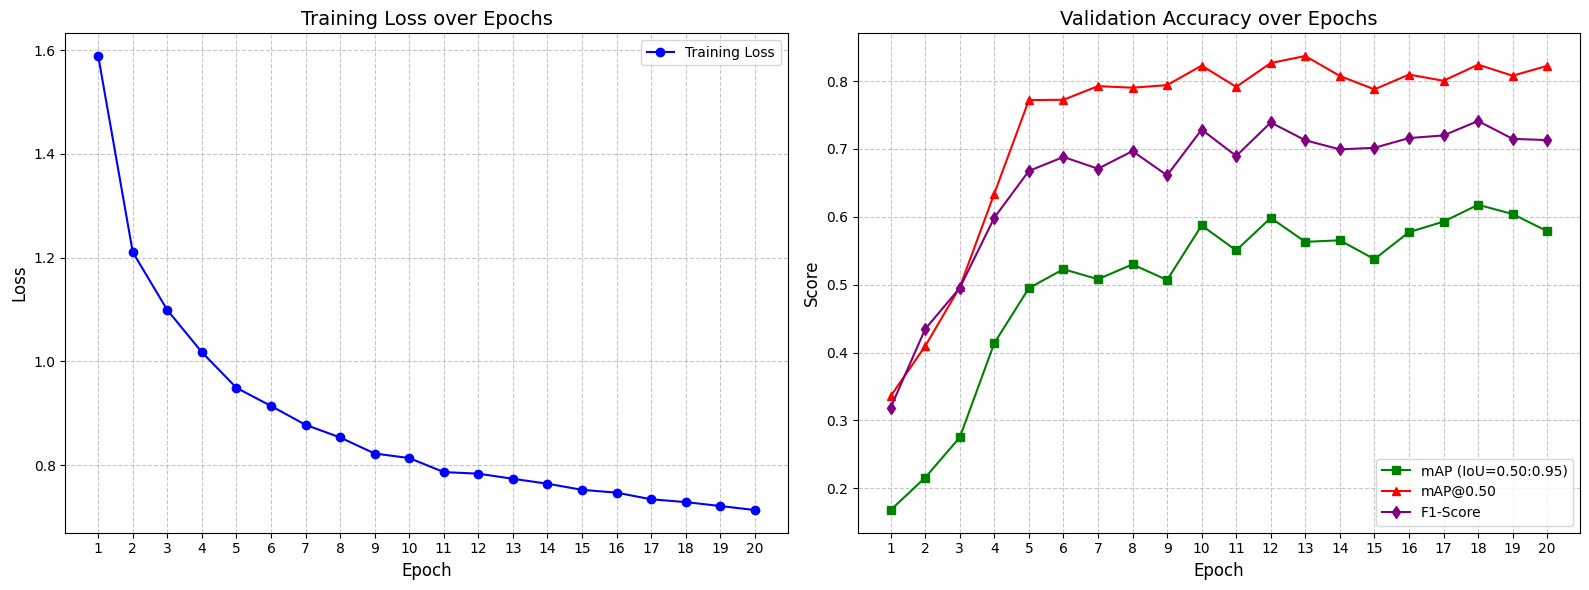

In [ ]:
if len(train_losses) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    epochs_range = range(1, len(train_losses) + 1)
    ax1.plot(epochs_range, train_losses, marker='o', linestyle='-', color='b', label='Training Loss')
    ax1.set_title('Training Loss over Epochs', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_xticks(epochs_range)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    ax2.plot(epochs_range, map_scores, marker='s', linestyle='-', color='g', label='mAP (IoU=0.50:0.95)')
    ax2.plot(epochs_range, map_50_scores, marker='^', linestyle='-', color='r', label='mAP@0.50')
    ax2.plot(epochs_range, f1_scores, marker='d', linestyle='-', color='purple', label='F1-Score')
    ax2.set_title('Validation Accuracy over Epochs', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_xticks(epochs_range)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Training was skipped (loaded saved weights), so there is no training curve to plot.")

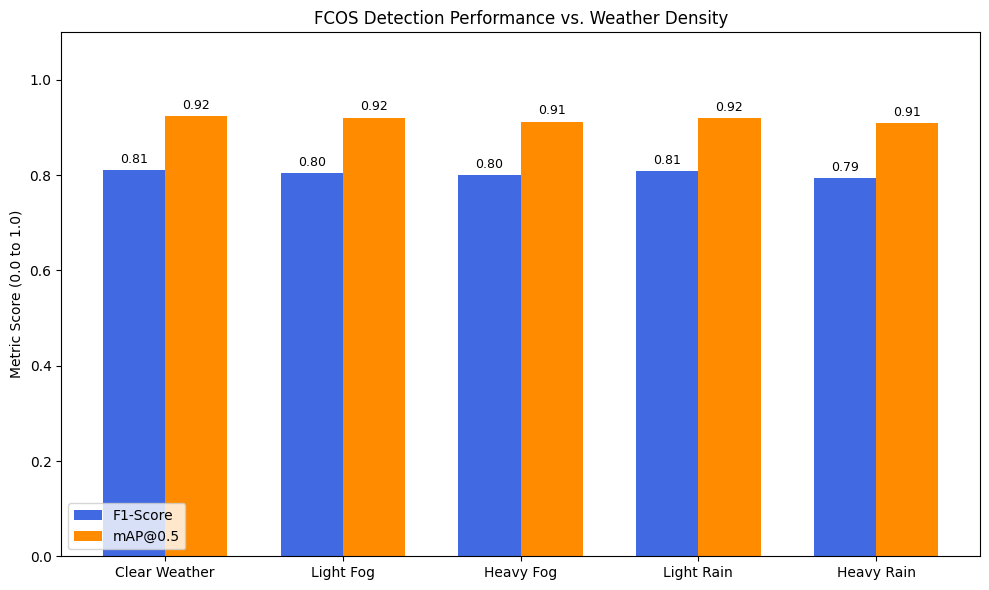

In [ ]:
conditions = list(performance_results.keys())
f1_scores_plot = [performance_results[c]['F1-Score'] for c in conditions]
map50_plot = [performance_results[c]['mAP@0.5'] for c in conditions]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, f1_scores_plot, width, label='F1-Score', color='royalblue')
rects2 = ax.bar(x + width/2, map50_plot, width, label='mAP@0.5', color='darkorange')

ax.set_ylabel('Metric Score (0.0 to 1.0)')
ax.set_title('FCOS Detection Performance vs. Weather Density')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend(loc='lower left')
ax.set_ylim([0, 1.1])

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

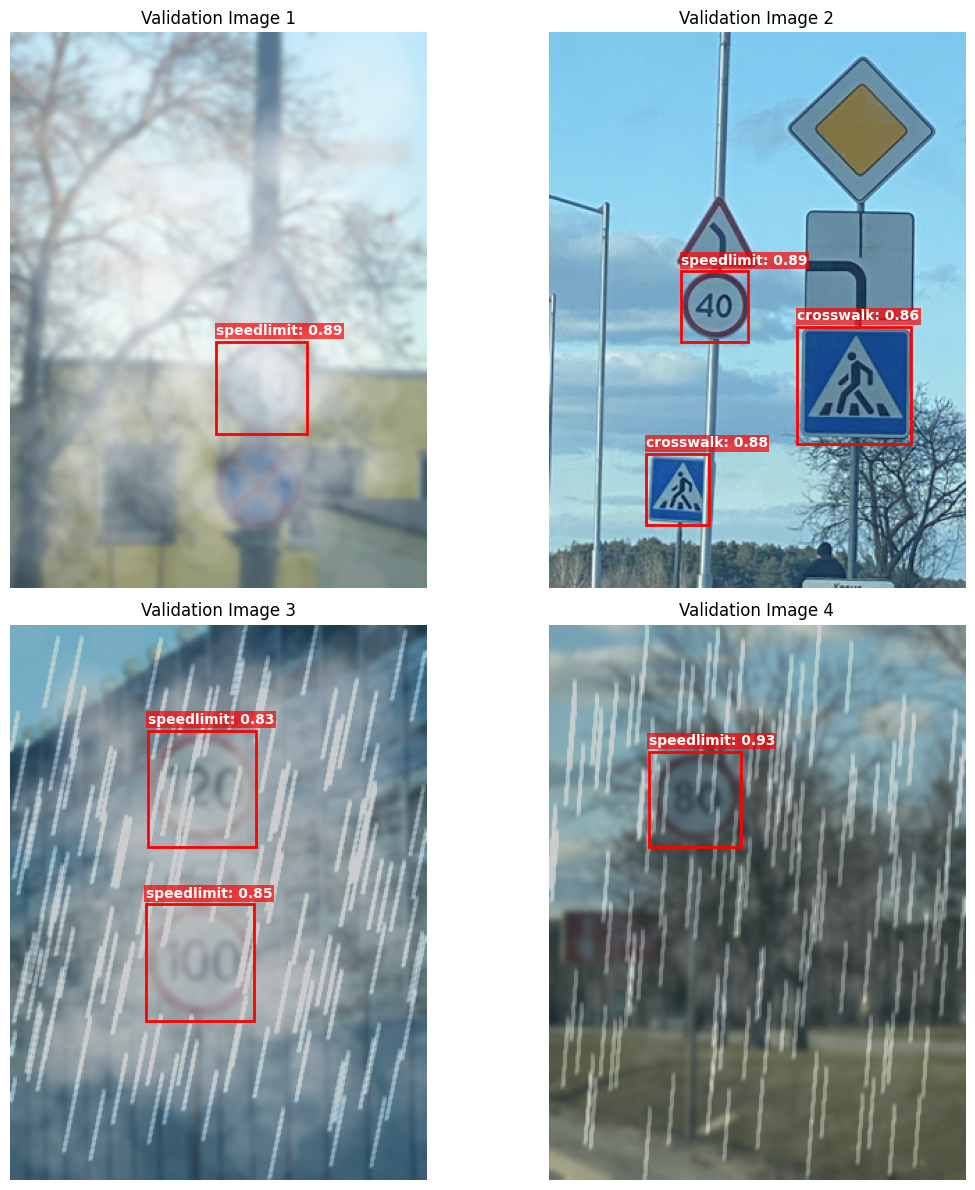

In [ ]:
model.eval()

val_loader = DataLoader(FogDataset(DATA_ROOT, 'val'), batch_size=4, shuffle=True, collate_fn=collate)
images, targets = next(iter(val_loader))
images_device = list(image.to(DEVICE) for image in images)

with torch.no_grad():
    outputs = model(images_device)

num_images = min(4, len(images))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

class_map = {1: 'crosswalk', 2: 'speedlimit', 3: 'stop', 4: 'trafficlight'}

for i in range(num_images):
    ax = axes[i]

    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)

    boxes = outputs[i]['boxes'].cpu().numpy()
    scores = outputs[i]['scores'].cpu().numpy()
    labels = outputs[i]['labels'].cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if score >= CONF_THRESH:
            x_min, y_min, x_max, y_max = box

            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

            class_name = class_map.get(label, f'Class {label}')
            label_text = f'{class_name}: {score:.2f}'
            ax.text(
                x_min, y_min - 5, label_text, color='white',
                fontsize=10, weight='bold',
                bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1)
            )

    ax.axis('off')
    ax.set_title(f"Validation Image {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import torch
from torchvision.transforms import functional as F

VIDEO_INPUT = "all_classes_test.mp4"
VIDEO_OUTPUT = "fcos_detected_traffic.mp4"

cap = cv2.VideoCapture(VIDEO_INPUT)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'MP4V')
out = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

class_map = {1: 'crosswalk', 2: 'speedlimit', 3: 'stop', 4: 'trafficlight'}
class_colors = {
    1: (255, 100, 0),
    2: (0, 200, 255),
    3: (0, 0, 255),
    4: (0, 255, 100),
}

FONT       = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.6
FONT_THICK = 2
BOX_THICK  = 3

print("Starting Video Processing...")
model.eval()

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img_tensor = F.to_tensor(img_rgb).to(DEVICE)

    with torch.no_grad():
        prediction = model([img_tensor])

    boxes  = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if score > 0.5:
            x1, y1, x2, y2 = box.astype(int)
            color = class_colors.get(label, (255, 255, 255))
            txt   = f"{class_map.get(label, 'Sign')}: {score:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, BOX_THICK)

            (tw, th), baseline = cv2.getTextSize(txt, FONT, FONT_SCALE, FONT_THICK)

            label_y = max(y1 - th - baseline - 6, 0)
            cv2.rectangle(frame,
                          (x1, label_y),
                          (x1 + tw + 6, label_y + th + baseline + 6),
                          color, cv2.FILLED)

            cv2.putText(frame, txt,
                        (x1 + 3, label_y + th + 3),
                        FONT, FONT_SCALE, (255, 255, 255), FONT_THICK)

    out.write(frame)
    frame_count += 1
    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames...")

cap.release()
out.release()
print(f"Finished! Video saved as: {VIDEO_OUTPUT}")

Starting Video Processing...
Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Processed 180 frames...
Finished! Video saved as: fcos_detected_traffic.mp4
